In [23]:
import sys
from pathlib import Path

import market_data

current_folder = str(Path().resolve())
if current_folder in sys.path:
    sys.path.remove(current_folder)

sys.path.insert(0, current_folder)

from contract import *
from enums import *
from market_data import *
from model import *
from pricer import *

import pricer
print(pricer.__file__)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

MarketData.initialize()

/Users/tothpatrik/QuantCourseBP/homeworks/9180744/my_homeworks/FlatVol_hazi/pricer.py


First I will test whether the implemented finite difference method works for all combinations for one option contract.

In [9]:
und = Stock.BLUECHIP_BANK
spot = MarketData.get_spot()[und]
option = EuropeanContract(und, PutCallFwd.CALL, LongShort.LONG, strike=spot, expiry=1.0)
model = FlatVolModel(und)
pricer = EuropeanAnalyticPricer(contract=option, model=model, params=Params())

analytic_delta = pricer.calc_delta(GreekMethod.ANALYTIC)
analytic_gamma = pricer.calc_gamma(GreekMethod.ANALYTIC)
#print(f'Analytic delta: {analytic_delta:.6f}\nAnalytic gamma: {analytic_gamma:.6f}')

results_data = []
for fm in FiniteMethod:
    for bm in BumpSizeMethod:
        pricer.finite_method = fm
        pricer.bumpsize_method = bm #default bump size of 0.01 is used
        delta = pricer.calc_delta(GreekMethod.BUMP)
        gamma = pricer.calc_gamma(GreekMethod.BUMP)

        results_data.append({
            'FD Method': fm.value,
            'BumpType': bm.value,
            'Delta': delta,
            'Delta Error': delta - analytic_delta,
            'Gamma': gamma,
            'Gamma Error': gamma - analytic_gamma
        })

results_data.append({
    'FD Method': 'ANALYTIC',
    'BumpType': '-',
    'Delta': analytic_delta,
    'Delta Error': None,
    'Gamma': analytic_gamma,
    'Gamma Error': None
})

df_greeks = pd.DataFrame(results_data)
df_greeks

,FD Method,BumpType,Delta,Delta Error,Gamma,Gamma Error
0,FORWARD,RELATIVE,0.631106,4.943000e-03,0.007500,-1.416336e-04
1,FORWARD,ABSOLUTE,0.626201,3.820707e-05,0.007641,-1.083042e-06
2,BACKWARD,RELATIVE,0.621159,-5.004162e-03,0.007782,1.401624e-04
3,BACKWARD,ABSOLUTE,0.626125,-3.821068e-05,0.007643,1.082551e-06
4,CENTRAL,RELATIVE,0.626132,-3.058064e-05,0.007642,-1.049390e-07
5,CENTRAL,ABSOLUTE,0.626163,-1.805718e-09,0.007642,1.808893e-10
6,ANALYTIC,-,0.626163,NaN,0.007642,NaN


Now lets compare the finite difference methods on a set of European call options with different strikes and expiries, then visualize the numerical error. First with the relative bump type then with absolute.

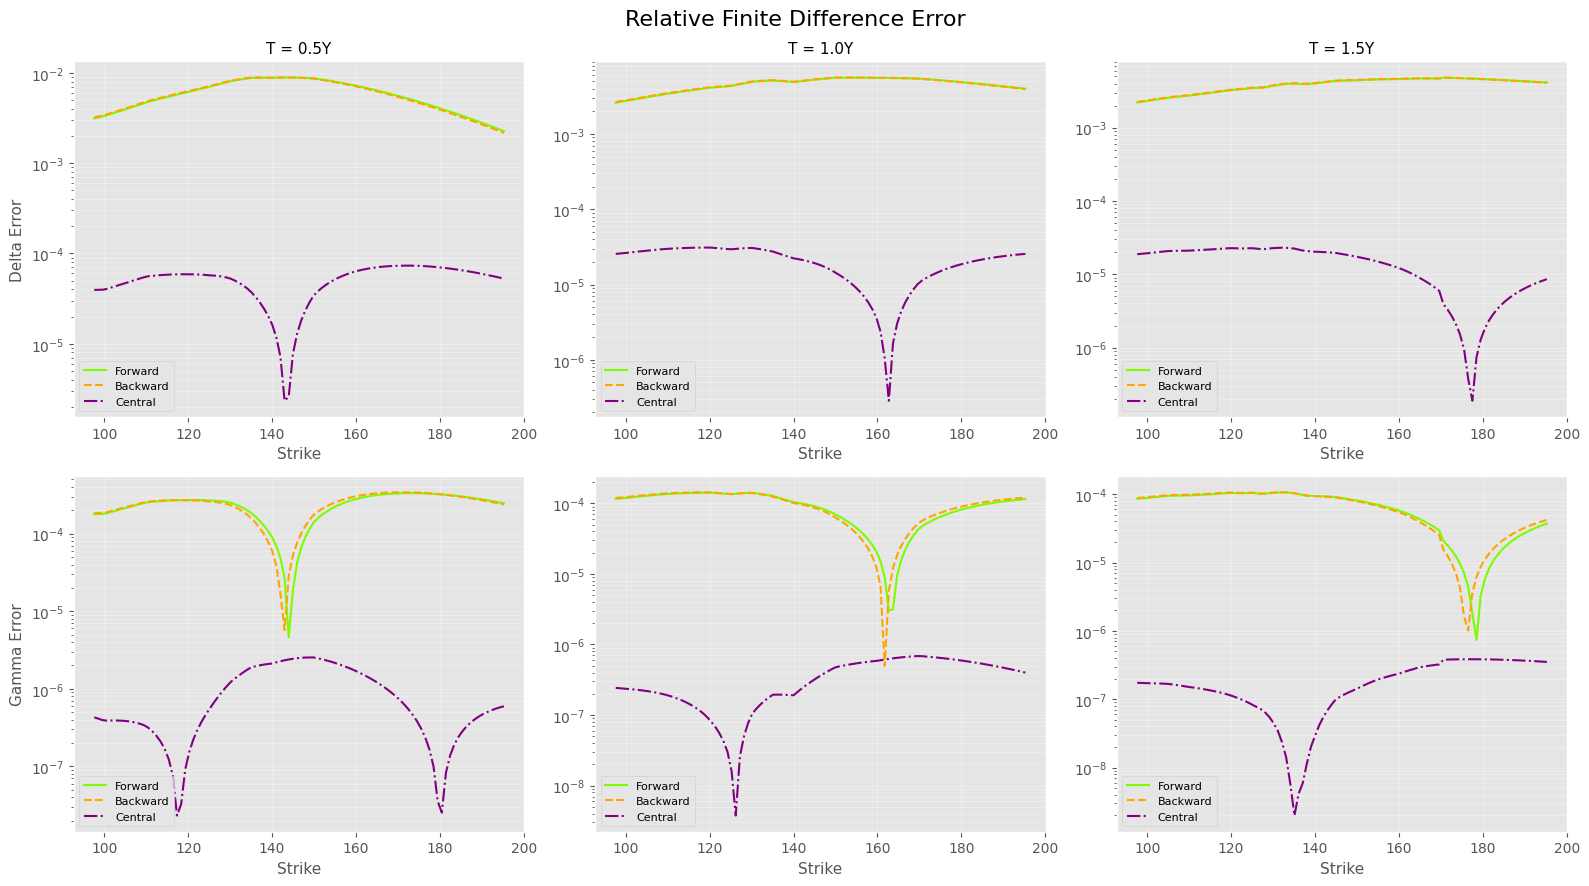

In [55]:
und = Stock.BLUECHIP_BANK
model = FlatVolModel(und)
spot = MarketData.get_spot()[und]
strikes = np.linspace(0.75*spot, 1.5*spot, 100)
expiries = [0.5, 1.0, 1.5]

finite_methods = [
    (FiniteMethod.FORWARD, 'Forward', '-', 'lawngreen'),
    (FiniteMethod.BACKWARD, 'Backward', '--', 'orange'),
    (FiniteMethod.CENTRAL, 'Central', '-.', 'purple')
    ]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 9))
fig.suptitle('Relative Finite Difference Error', fontsize=16)

for col_idx, T in enumerate(expiries):
    ax_delta = axes[0, col_idx]
    ax_gamma = axes[1, col_idx]
    ax_delta.set_title(f'T = {T}Y', fontsize=11)

    err_delta = {fm[0]: [] for fm in finite_methods}
    err_gamma = {fm[0]: [] for fm in finite_methods}

    for K in strikes:
        contract = EuropeanContract(und, PutCallFwd.CALL, LongShort.LONG, K, T)
        pricer = EuropeanAnalyticPricer(contract, model, Params())
        delta_analytic = pricer.calc_delta(GreekMethod.ANALYTIC)
        gamma_analytic = pricer.calc_gamma(GreekMethod.ANALYTIC)

        pricer.bumpsize_method = BumpSizeMethod.RELATIVE
        for fm_type, _, _, _ in finite_methods:
            pricer.finite_method = fm_type

            delta_fd = pricer.calc_delta(GreekMethod.BUMP)
            gamma_fd = pricer.calc_gamma(GreekMethod.BUMP)
            err_delta[fm_type].append(abs(delta_fd - delta_analytic))
            err_gamma[fm_type].append(abs(gamma_fd - gamma_analytic))

    for fm_type, label, ls, color in finite_methods:
        ax_delta.plot(strikes, err_delta[fm_type], label=label, linestyle=ls, color=color)
        ax_gamma.plot(strikes, err_gamma[fm_type], label=label, linestyle=ls, color=color)

    ax_delta.set_yscale('log')
    ax_delta.grid(True, which="both", ls="-", alpha=0.3)
    ax_delta.set_xlabel('Strike', fontsize=11)
    ax_delta.legend(fontsize=8, loc='lower left')
    if col_idx == 0:
        ax_delta.set_ylabel('Delta Error', fontsize=11)

    ax_gamma.set_yscale('log')
    ax_gamma.grid(True, which="both", ls="-", alpha=0.3)
    ax_gamma.set_xlabel('Strike', fontsize=11)
    ax_gamma.legend(fontsize=8, loc='lower left')
    if col_idx == 0:
        ax_gamma.set_ylabel('Gamma Error', fontsize=11)

plt.style.use('ggplot')
plt.tight_layout()
plt.show()


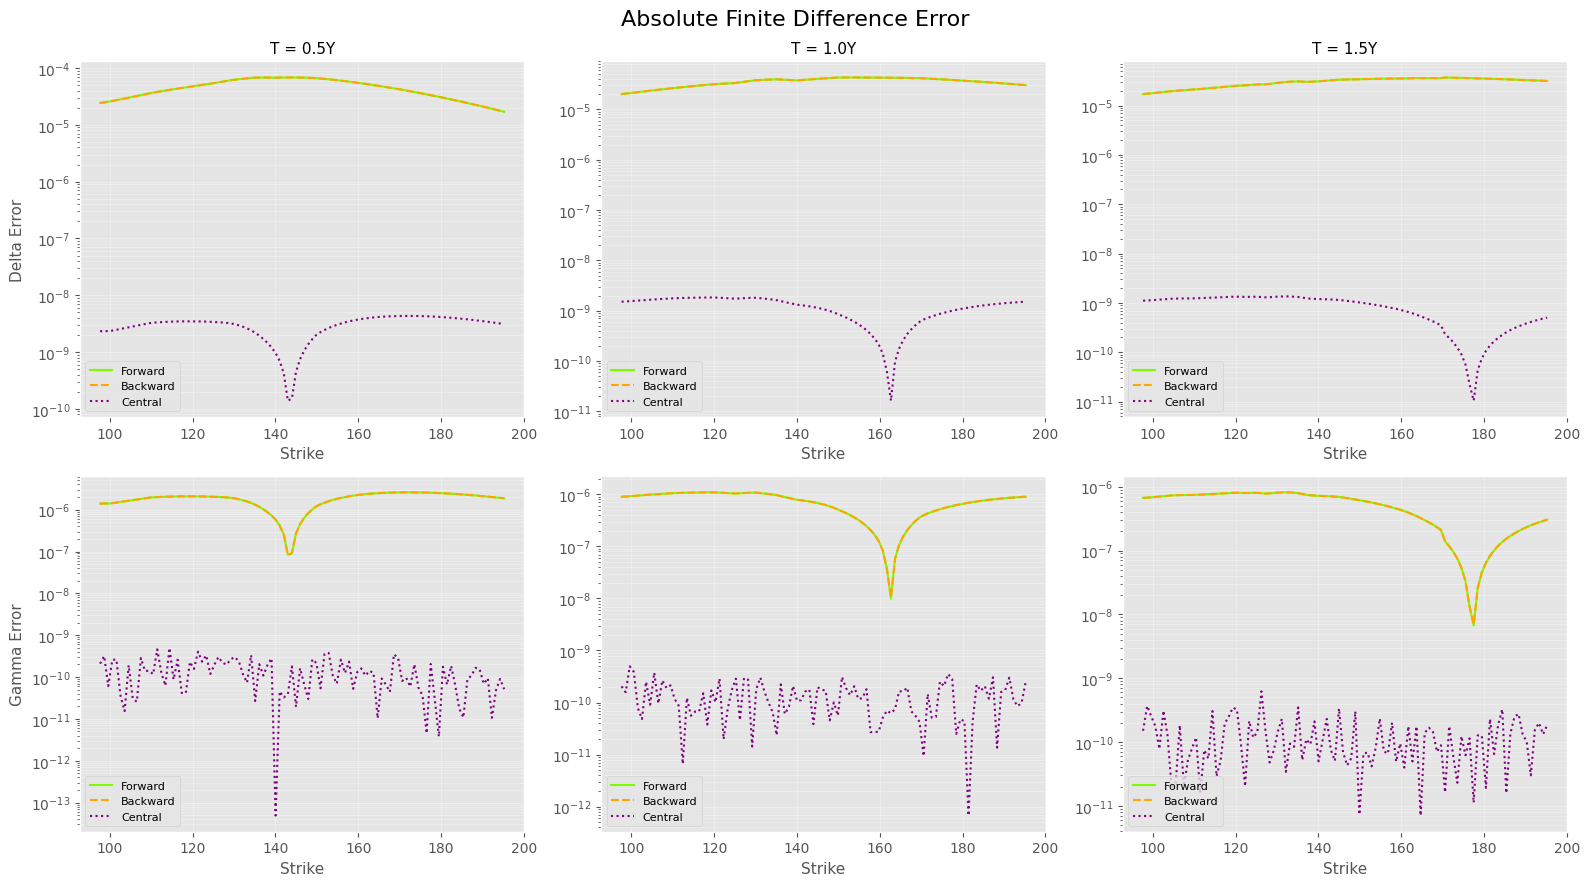

In [54]:
und = Stock.BLUECHIP_BANK
model = FlatVolModel(und)
spot = MarketData.get_spot()[und]
strikes = np.linspace(0.75*spot, 1.5*spot, 100)
expiries = [0.5, 1.0, 1.5]

finite_methods = [
    (FiniteMethod.FORWARD, 'Forward', '-', 'lawngreen'),
    (FiniteMethod.BACKWARD, 'Backward', '--', 'orange'),
    (FiniteMethod.CENTRAL, 'Central', ':', 'purple')
    ]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 9))
fig.suptitle('Absolute Finite Difference Error', fontsize=16)

for col_idx, T in enumerate(expiries):
    ax_delta = axes[0, col_idx]
    ax_gamma = axes[1, col_idx]
    ax_delta.set_title(f'T = {T}Y', fontsize=11)

    err_delta = {fm[0]: [] for fm in finite_methods}
    err_gamma = {fm[0]: [] for fm in finite_methods}

    for K in strikes:
        contract = EuropeanContract(und, PutCallFwd.CALL, LongShort.LONG, K, T)
        pricer = EuropeanAnalyticPricer(contract, model, Params())
        delta_analytic = pricer.calc_delta(GreekMethod.ANALYTIC)
        gamma_analytic = pricer.calc_gamma(GreekMethod.ANALYTIC)

        pricer.bumpsize_method = BumpSizeMethod.ABSOLUTE
        for fm_type, _, _, _ in finite_methods:
            pricer.finite_method = fm_type

            delta_fd = pricer.calc_delta(GreekMethod.BUMP)
            gamma_fd = pricer.calc_gamma(GreekMethod.BUMP)
            err_delta[fm_type].append(abs(delta_fd - delta_analytic))
            err_gamma[fm_type].append(abs(gamma_fd - gamma_analytic))

    for fm_type, label, ls, color in finite_methods:
        ax_delta.plot(strikes, err_delta[fm_type], label=label, linestyle=ls, color=color)
        ax_gamma.plot(strikes, err_gamma[fm_type], label=label, linestyle=ls, color=color)

    ax_delta.set_yscale('log')
    ax_delta.grid(True, which="both", ls="-", alpha=0.3)
    ax_delta.set_xlabel('Strike', fontsize=11)
    ax_delta.legend(fontsize=8, loc='lower left')
    if col_idx == 0:
        ax_delta.set_ylabel('Delta Error', fontsize=11)

    ax_gamma.set_yscale('log')
    ax_gamma.grid(True, which="both", ls="-", alpha=0.3)
    ax_gamma.set_xlabel('Strike', fontsize=11)
    ax_gamma.legend(fontsize=8, loc='lower left')
    if col_idx == 0:
        ax_gamma.set_ylabel('Gamma Error', fontsize=11)

plt.style.use('ggplot')
plt.tight_layout()
plt.show()

Seemingly the central finite difference method has the better performance for both relative and absolute bump type. So I am going to stick with the central finite method.

     Optimal Bump Sizes (Central Difference)      
--------------------------------------------------
--- RELATIVE Bumping ---
Lowest Delta Error: 5.54e-13 achieved at bump size h = 1.00e-06
Lowest Gamma Error: 9.17e-12 achieved at bump size h = 1.39e-04

--- ABSOLUTE Bumping ---
Lowest Delta Error: 2.20e-12 achieved at bump size h = 5.18e-04
Lowest Gamma Error: 8.43e-12 achieved at bump size h = 1.93e-02



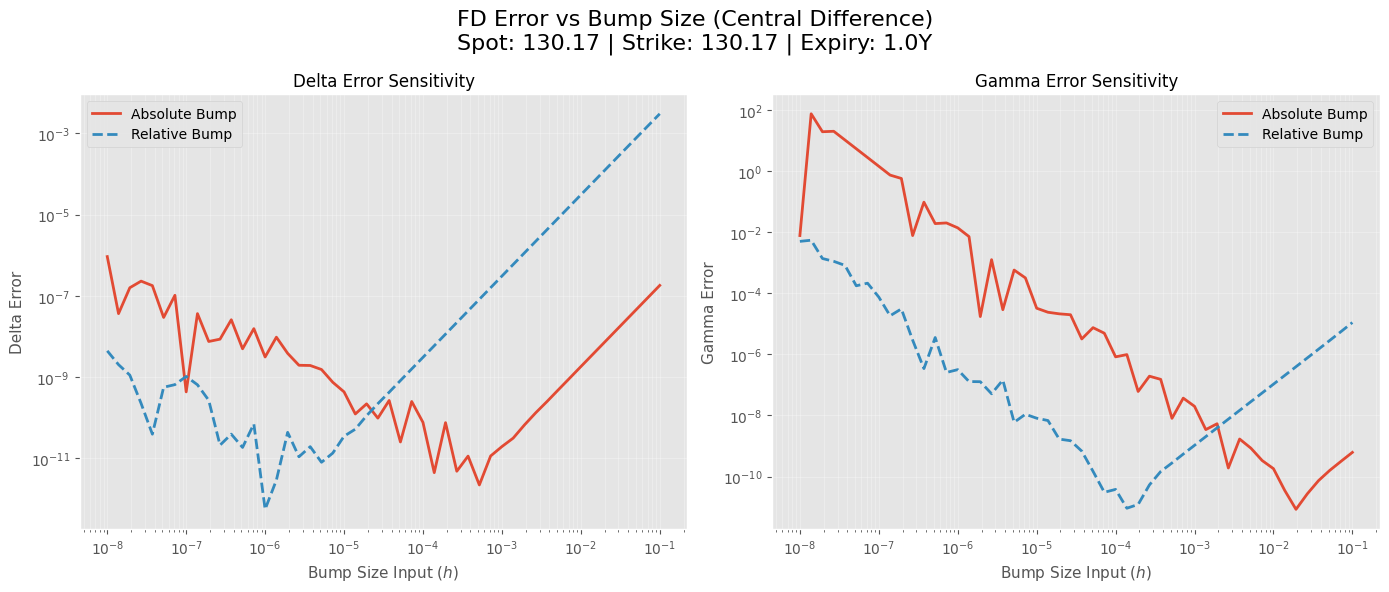

In [60]:
und = Stock.BLUECHIP_BANK
model = FlatVolModel(und)
spot = MarketData.get_spot()[und]
option = EuropeanContract(und, PutCallFwd.CALL, LongShort.LONG, strike=spot, expiry=1.0)
pricer_ref = EuropeanAnalyticPricer(option, model, Params())

delta_true = pricer_ref.calc_delta(GreekMethod.ANALYTIC)
gamma_true = pricer_ref.calc_gamma(GreekMethod.ANALYTIC)

bump_sizes = np.logspace(-8, -1, 50)

err_delta = {BumpSizeMethod.ABSOLUTE: [], BumpSizeMethod.RELATIVE: []}
err_gamma = {BumpSizeMethod.ABSOLUTE: [], BumpSizeMethod.RELATIVE: []}

pricer_ref.finite_method = FiniteMethod.CENTRAL
for bm in BumpSizeMethod:
    pricer_ref.bumpsize_method = bm
    for bs in bump_sizes:
        pricer_ref.relative_bump_size = bs
        delta_fd = pricer_ref.calc_delta(GreekMethod.BUMP)
        gamma_fd = pricer_ref.calc_gamma(GreekMethod.BUMP)
        err_delta[bm].append(abs(delta_fd - delta_true))
        err_gamma[bm].append(abs(gamma_fd - gamma_true))

print(f"{'Optimal Bump Sizes (Central Difference)':^50}")
print("-" * 50)

for bm in BumpSizeMethod:
    idx_best_delta = np.argmin(err_delta[bm])
    idx_best_gamma = np.argmin(err_gamma[bm])
    best_bs_delta = bump_sizes[idx_best_delta]
    best_bs_gamma = bump_sizes[idx_best_gamma]
    min_err_delta = err_delta[bm][idx_best_delta]
    min_err_gamma = err_gamma[bm][idx_best_gamma]

    print(f"--- {bm.value} Bumping ---")
    print(f"Lowest Delta Error: {min_err_delta:.2e} achieved at bump size h = {best_bs_delta:.2e}")
    print(f"Lowest Gamma Error: {min_err_gamma:.2e} achieved at bump size h = {best_bs_gamma:.2e}\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'FD Error vs Bump Size (Central Difference)\nSpot: {spot:.2f} | Strike: {spot:.2f} | Expiry: 1.0Y',
             fontsize=16)

# Delta Plot
ax1.plot(bump_sizes, err_delta[BumpSizeMethod.ABSOLUTE], label='Absolute Bump', color='C0', lw=2)
ax1.plot(bump_sizes, err_delta[BumpSizeMethod.RELATIVE], label='Relative Bump', color='C1', lw=2, linestyle='--')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Bump Size Input ($h$)', fontsize=11)
ax1.set_ylabel('Delta Error', fontsize=11)
ax1.set_title('Delta Error Sensitivity', fontsize=12)
ax1.legend()
ax1.grid(True, which="both", ls="-", alpha=0.3)

# Gamma Plot
ax2.plot(bump_sizes, err_gamma[BumpSizeMethod.ABSOLUTE], label='Absolute Bump', color='C0', lw=2)
ax2.plot(bump_sizes, err_gamma[BumpSizeMethod.RELATIVE], label='Relative Bump', color='C1', lw=2, linestyle='--')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Bump Size Input ($h$)', fontsize=11)
ax2.set_ylabel('Gamma Error', fontsize=11)
ax2.set_title('Gamma Error Sensitivity', fontsize=12)
ax2.legend()
ax2.grid(True, which="both", ls="-", alpha=0.3)

plt.style.use('ggplot')
plt.tight_layout()
plt.show()